# NSRDB GOES Full Disc Puerto Rico Request Planner

This notebook is the source-of-truth Jupytext workflow for planning,
submitting, and summarizing NSRDB GOES Full Disc archive requests for Puerto
Rico.

Heavy planning, parsing, archive, and summary helpers now live in
`utils/nsrdb_ingest.py` so this notebook can stay narrative-first and sync
cleanly between `.py` and `.ipynb`.

In [1]:
from __future__ import annotations

import importlib
import json
import os
import sys
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd


def resolve_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if any((candidate / marker).exists() for marker in ("project_rules.md", ".git")):
            return candidate
    return current


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_CONTROLS = {
    "NSRDB_CASE_STUDY_MUNICIPALITIES": "San Juan,Isabela",
    "NSRDB_PLAN_SCOPE": "all_pr",
    "NSRDB_FETCH_SCOPE": "case_study",
    "NSRDB_ARCHIVE_WORKFLOW_MODE": "status_only",
    "NSRDB_CSV_FALLBACK_MODE": "disabled",
    "NSRDB_RUN_BATCH_LIMIT": "20",
}

ARCHIVE_WORKFLOW_MODE_HELP = {
    "status_only": "Inspect the plan and archive status only.",
    "submit": "Submit missing fetch-scope archive requests.",
    "download": "Submit if needed, then poll and download ready archive zips.",
    "extract": "Download stage plus local zip extraction.",
    "normalize": "Extract stage plus CSV-to-parquet normalization.",
}

REQUEST_WEIGHT_GUIDANCE = [
    "request_weight_pct is the percent of the NSRDB per-request cap used by a polygon batch.",
    "It is not a priority score and should only be read as an API limit meter.",
    "Values above 100 need more spatial splitting before submission.",
]


def apply_notebook_controls(control_values: dict[str, str]) -> dict[str, str]:
    for env_name, env_value in control_values.items():
        os.environ[env_name] = str(env_value)
    return control_values


def show_frame(frame: pd.DataFrame | gpd.GeoDataFrame | None, rows: int = 20) -> None:
    if frame is None or len(frame) == 0:
        print("No rows.")
        return
    print(frame.head(rows).to_string(index=False))


apply_notebook_controls(NOTEBOOK_CONTROLS)
NOTEBOOK_CONTROLS

{'NSRDB_CASE_STUDY_MUNICIPALITIES': 'San Juan,Isabela',
 'NSRDB_PLAN_SCOPE': 'all_pr',
 'NSRDB_FETCH_SCOPE': 'case_study',
 'NSRDB_ARCHIVE_WORKFLOW_MODE': 'status_only',
 'NSRDB_CSV_FALLBACK_MODE': 'disabled',
 'NSRDB_RUN_BATCH_LIMIT': '20'}

## Workflow Controls

The notebook keeps three things separate:
1. build polygon batches for the planning scope
2. limit live archive work to the fetch scope
3. keep the direct CSV fallback visibly secondary to the archive path

`request_weight_pct` is only the share of the NSRDB per-request cap used by a
polygon batch. It is not a priority score.

In [2]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception:
    widgets = None
    display = None

if widgets is None:
    print("ipywidgets is unavailable in this kernel. Edit NOTEBOOK_CONTROLS in Cell 2 instead.")
    print(json.dumps(NOTEBOOK_CONTROLS, indent=2))
else:
    plan_scope_widget = widgets.Dropdown(
        options=[("All Puerto Rico", "all_pr"), ("Case study only", "case_study")],
        value=NOTEBOOK_CONTROLS["NSRDB_PLAN_SCOPE"],
        description="Plan",
    )
    fetch_scope_widget = widgets.Dropdown(
        options=[("Case study", "case_study"), ("All Puerto Rico", "all_pr"), ("Disable archive", "none")],
        value=NOTEBOOK_CONTROLS["NSRDB_FETCH_SCOPE"],
        description="Fetch",
    )
    archive_mode_widget = widgets.Dropdown(
        options=[
            ("Inspect only", "status_only"),
            ("Submit", "submit"),
            ("Download", "download"),
            ("Extract", "extract"),
            ("Normalize", "normalize"),
        ],
        value=NOTEBOOK_CONTROLS["NSRDB_ARCHIVE_WORKFLOW_MODE"],
        description="Archive",
    )
    csv_mode_widget = widgets.Dropdown(
        options=[("Disabled", "disabled"), ("Plan only", "plan_only"), ("Execute", "execute")],
        value=NOTEBOOK_CONTROLS["NSRDB_CSV_FALLBACK_MODE"],
        description="CSV",
    )
    batch_limit_widget = widgets.BoundedIntText(
        value=int(NOTEBOOK_CONTROLS["NSRDB_RUN_BATCH_LIMIT"]),
        min=0,
        max=500,
        description="Limit",
    )
    summary_output = widgets.Output()

    def sync_controls(*_):
        NOTEBOOK_CONTROLS.update(
            {
                "NSRDB_PLAN_SCOPE": plan_scope_widget.value,
                "NSRDB_FETCH_SCOPE": fetch_scope_widget.value,
                "NSRDB_ARCHIVE_WORKFLOW_MODE": archive_mode_widget.value,
                "NSRDB_CSV_FALLBACK_MODE": csv_mode_widget.value,
                "NSRDB_RUN_BATCH_LIMIT": str(batch_limit_widget.value),
            }
        )
        apply_notebook_controls(NOTEBOOK_CONTROLS)
        summary_output.clear_output()
        with summary_output:
            print(json.dumps(NOTEBOOK_CONTROLS, indent=2))
            print()
            print("Archive mode:", ARCHIVE_WORKFLOW_MODE_HELP[archive_mode_widget.value])
            print()
            for line in REQUEST_WEIGHT_GUIDANCE:
                print(f"- {line}")

    for widget in (
        plan_scope_widget,
        fetch_scope_widget,
        archive_mode_widget,
        csv_mode_widget,
        batch_limit_widget,
    ):
        widget.observe(sync_controls, names="value")

    sync_controls()
    display(
        widgets.VBox(
            [
                widgets.HBox([plan_scope_widget, fetch_scope_widget]),
                widgets.HBox([archive_mode_widget, csv_mode_widget, batch_limit_widget]),
                summary_output,
            ]
        )
    )

In [3]:
apply_notebook_controls(NOTEBOOK_CONTROLS)

from utils import nsrdb_ingest as workflow

workflow = importlib.reload(workflow)

archive_submit_rows = pd.DataFrame()
archive_download_rows = pd.DataFrame()
archive_extract_rows = pd.DataFrame()
archive_manifest = pd.DataFrame()
csv_request_plan = pd.DataFrame()
csv_download_rows = pd.DataFrame()
site_discovery_log = pd.DataFrame()
discovered_sites = gpd.GeoDataFrame(columns=["site_id", "latitude", "longitude", "geometry"], geometry="geometry", crs="EPSG:4326")
monthly_flux_means = pd.DataFrame()
annual_flux_means = pd.DataFrame()
multiyear_flux_means = pd.DataFrame()

workflow.NSRDB_ROOT.mkdir(parents=True, exist_ok=True)
workflow.RAW_ROOT.mkdir(parents=True, exist_ok=True)
workflow.NORMALIZED_ROOT.mkdir(parents=True, exist_ok=True)

if not workflow.NSRDB_API_KEY:
    raise RuntimeError("NSRDB_API_KEY (or NREL_API_KEY / NLR_API_KEY) is not configured.")

db_path = workflow.resolve_db_path()
print(f"DuckDB: {db_path}")
print(f"NSRDB root: {workflow.NSRDB_ROOT}")
print(f"Case study municipalities: {', '.join(workflow.CASE_STUDY_MUNICIPALITIES)}")
print(f"Plan scope: {workflow.PLAN_SCOPE_LABEL}")
print(f"Archive fetch scope: {workflow.FETCH_SCOPE_LABEL}")
print(f"Archive workflow mode: {workflow.ARCHIVE_WORKFLOW_MODE}")
print(f"CSV fallback mode: {workflow.CSV_FALLBACK_MODE}")
print(
    "Per-run batch limit: "
    + (f"{workflow.MAX_REQUESTS_THIS_RUN:,}" if workflow.MAX_REQUESTS_THIS_RUN is not None else "all eligible batches")
)
print(f"Dataset: {workflow.GOES_FULL_DISC_DATASET}")
print(f"Years: {', '.join(str(year) for year in workflow.YEARS)}")
print(f"Interval: {workflow.INTERVAL_MINUTES} minutes")
print(f"Attributes: {', '.join(workflow.ATTRIBUTES)}")

con = workflow.connect(db_path)
all_municipalities = workflow.load_puerto_rico_municipalities(con)
plan_municipalities = workflow.load_target_municipalities(con, workflow.PLAN_SCOPE_MUNICIPALITIES)
fetch_municipalities = (
    workflow.empty_municipality_frame()
    if workflow.FETCH_SCOPE_MUNICIPALITIES is None
    else workflow.load_target_municipalities(con, workflow.FETCH_SCOPE_MUNICIPALITIES)
)
con.close()

if all_municipalities.empty:
    raise RuntimeError("Puerto Rico municipalities are unavailable in DuckDB.")
if plan_municipalities.empty:
    raise RuntimeError("Planning-scope municipalities are unavailable in DuckDB.")

available_municipalities = set(all_municipalities["municipio"].astype(str))
missing_case_study = sorted(set(workflow.CASE_STUDY_MUNICIPALITIES) - available_municipalities)
if missing_case_study:
    raise RuntimeError(
        "Case-study municipalities are missing from the canonical county table: " + ", ".join(missing_case_study)
    )
if workflow.FETCH_SCOPE_MUNICIPALITIES is not None and fetch_municipalities.empty:
    raise RuntimeError("The current fetch scope does not resolve to any municipality geometries.")

plan_area_geometry = plan_municipalities.geometry.union_all()
plan_site_count_wkt = workflow.simplify_wkt_for_site_count(plan_area_geometry.wkt)
print(f"plan-scope WKT chars: {len(plan_area_geometry.wkt):,} -> {len(plan_site_count_wkt):,}")
plan_area_site_count = workflow.query_site_count(plan_site_count_wkt, api_key=workflow.NSRDB_API_KEY)
plan_area_weight = workflow.compute_request_weight(
    plan_area_site_count,
    len(workflow.ATTRIBUTES),
    len(workflow.YEARS),
    workflow.INTERVAL_MINUTES,
)
max_sites = workflow.max_sites_per_request(
    attribute_count=len(workflow.ATTRIBUTES),
    year_count=len(workflow.YEARS),
    interval_minutes=workflow.INTERVAL_MINUTES,
    max_request_weight=workflow.MAX_REQUEST_WEIGHT,
)

if workflow.FETCH_SCOPE_MUNICIPALITIES is None:
    fetch_area_geometry = None
    fetch_area_site_count = 0
else:
    fetch_area_geometry = fetch_municipalities.geometry.union_all()
    if workflow.FETCH_SCOPE_MUNICIPALITIES == workflow.PLAN_SCOPE_MUNICIPALITIES:
        fetch_area_site_count = plan_area_site_count
    else:
        fetch_site_count_wkt = workflow.simplify_wkt_for_site_count(fetch_area_geometry.wkt)
        fetch_area_site_count = workflow.query_site_count(fetch_site_count_wkt, api_key=workflow.NSRDB_API_KEY)

print(f"planned-area site count: {plan_area_site_count:,}")
if workflow.FETCH_SCOPE_MUNICIPALITIES is None:
    print("current fetch-scope site count: archive execution disabled")
elif workflow.FETCH_SCOPE_MUNICIPALITIES == workflow.PLAN_SCOPE_MUNICIPALITIES:
    print(f"current fetch-scope site count: {fetch_area_site_count:,} (same as plan scope)")
else:
    print(f"current fetch-scope site count: {fetch_area_site_count:,}")
print(f"max sites per request at current settings: {max_sites:,}")
print(f"planned-area request weight: {plan_area_weight:,} / {workflow.MAX_REQUEST_WEIGHT:,}")

plan = workflow.plan_download_batches(
    plan_area_geometry,
    attributes=workflow.ATTRIBUTES,
    years=workflow.YEARS,
    interval_minutes=workflow.INTERVAL_MINUTES,
    api_key=workflow.NSRDB_API_KEY,
    max_depth=workflow.MAX_BATCH_SPLIT_DEPTH,
    min_area_km2=workflow.MIN_BATCH_AREA_KM2,
)
if plan.empty:
    raise RuntimeError("NSRDB request plan is empty; check the target-area geometry and site-count response.")

plan = workflow.namespace_plan_batch_ids(plan, scope_stem=workflow.PLAN_SCOPE_STEM)
workflow.write_request_plan(plan)
print(f"planned request batches: {len(plan):,}")
print(f"request plan parquet: {workflow.REQUEST_PLAN_PATH}")
print(f"request plan geojson: {workflow.REQUEST_PLAN_GEOJSON}")
print(plan[["batch_id", "split_depth", "site_count", "request_weight_pct", "area_km2", "over_limit"]].to_string(index=False))

request_batch_status = workflow.build_request_batch_status(
    plan,
    all_municipalities,
    fetch_municipalities,
    fetch_scope_enabled=workflow.FETCH_SCOPE_MUNICIPALITIES is not None,
)
batch_status_summary = workflow.build_batch_status_summary(request_batch_status)
if not batch_status_summary.empty:
    print(batch_status_summary.to_string(index=False))
workflow.preview_table(
    "request batch status",
    request_batch_status[
        [
            "batch_id",
            "display_status",
            "site_count",
            "request_weight_pct",
            "covered_municipalities",
            "fetch_scope_municipalities",
        ]
    ],
    rows=min(20, len(request_batch_status)),
)
workflow.print_request_weight_guidance()
csv_request_weight = workflow.compute_request_weight(1, len(workflow.ATTRIBUTES), 1, workflow.INTERVAL_MINUTES)
print(f"direct CSV request weight per site-year: {csv_request_weight:,}")

DuckDB: /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/PR_PV_plan_data.duckdb
NSRDB root: /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb
Case study municipalities: San Juan, Isabela
Plan scope: Puerto Rico
Archive fetch scope: San Juan + Isabela
Archive workflow mode: normalize
CSV fallback mode: disabled
Per-run batch limit: 25
Dataset: nsrdb-GOES-full-disc-v4-0-0
Years: 2018, 2019, 2020, 2021, 2022, 2023, 2024
Interval: 30 minutes
Attributes: air_temperature, clearsky_dhi, clearsky_dni, clearsky_ghi, dhi, dni, ghi, solar_zenith_angle, surface_albedo
plan-scope WKT chars: 71,571 -> 2,606
planned-area site count: 1,889
current fetch-scope site count: 57
max sites per request at current settings: 158
planned-area request weight: 2,085,002,640 / 175,000,100
planned request batches: 28
request plan parquet: /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/puerto_rico_request_plan.parquet
request plan geojson: /home/asvnpr/Documents/repos/PLAN

## Request-Plan QA and Current Status

The map below always shows the full planning scope. The status layer then
distinguishes polygons inside the current fetch scope from batches that are
only being proposed for later work.

In [4]:
if request_batch_status.empty:
    print("No request-batch status table is available.")
else:
    ledger_activity_summary = workflow.build_ledger_activity_summary()
    if not ledger_activity_summary.empty:
        print(ledger_activity_summary.to_string(index=False))
        csv_dry_runs = int(
            ledger_activity_summary.loc[
                (ledger_activity_summary["request_format"] == "csv")
                & (ledger_activity_summary["status"] == "dry_run"),
                "request_count",
            ].sum()
        )
        if csv_dry_runs:
            print(
                f"Note: {csv_dry_runs:,} CSV dry-run ledger rows are older point-year fallback plans, not polygon archive batches."
            )

## Request-Plan Preview

Visual QA for the plan itself plus the current archive status by batch.

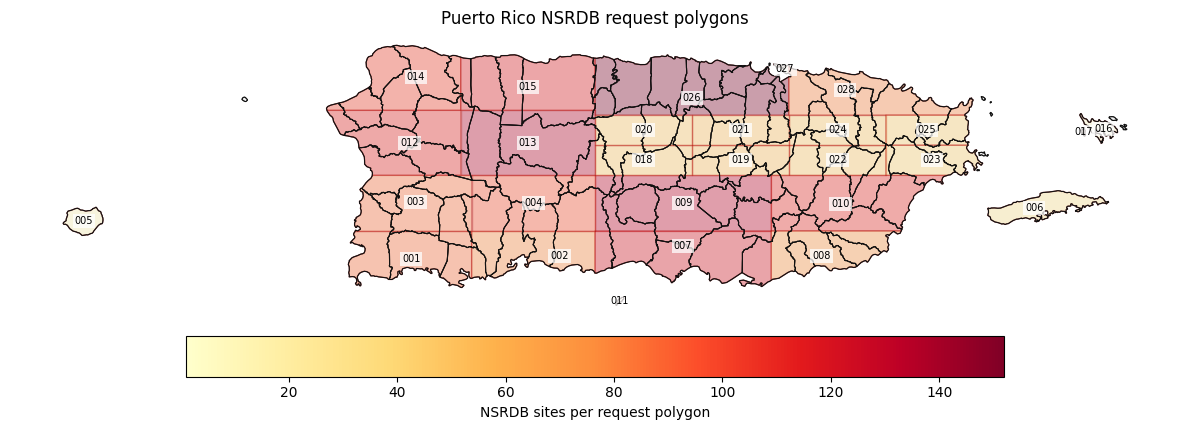

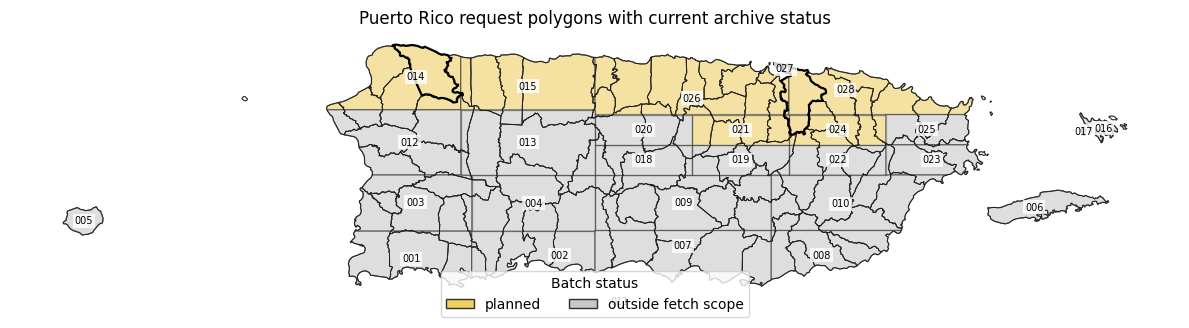

In [5]:
if plan.empty:
    print("No request plan is available.")
else:
    workflow.plot_request_plan(all_municipalities, plan)
    workflow.plot_request_status_map(
        all_municipalities,
        request_batch_status,
        fetch_municipalities=fetch_municipalities if workflow.FETCH_SCOPE_MUNICIPALITIES is not None else None,
    )

## Archive Request Submission and Download Queue

The polygon `.json` endpoint is the primary path for study-area coverage. The
`NSRDB_ARCHIVE_WORKFLOW_MODE` control decides the furthest stage this run will
execute. When the mode is `status_only`, the notebook shows candidates but does
not append new dry-run rows to the ledger.

In [6]:
if request_batch_status.empty:
    print("No request-batch status table is available.")
else:
    submission_candidates = request_batch_status.loc[
        request_batch_status["in_fetch_scope"]
        & request_batch_status["display_status"].astype(str).isin(["planned", "dry_run"])
    ].copy()
    print(f"submission candidates inside the current fetch scope: {len(submission_candidates):,}")

    if submission_candidates.empty:
        print("archive submission skipped: no fetch-scope batches are waiting to be submitted.")
    elif not workflow.SUBMIT_ARCHIVE_REQUESTS:
        workflow.preview_table(
            "archive submission candidates",
            submission_candidates[["batch_id", "site_count", "request_weight_pct", "fetch_scope_municipalities"]],
            rows=min(10, len(submission_candidates)),
        )
        print(f"archive submission not executed because NSRDB_ARCHIVE_WORKFLOW_MODE={workflow.ARCHIVE_WORKFLOW_MODE}.")
    else:
        archive_submit_rows = workflow.submit_planned_requests(
            submission_candidates,
            api_key=workflow.NSRDB_API_KEY,
            email=workflow.NSRDB_EMAIL,
            years=workflow.YEARS,
            attributes=workflow.ATTRIBUTES,
            interval_minutes=workflow.INTERVAL_MINUTES,
            ledger_path=workflow.DEFAULT_LEDGER_PATH,
            max_requests=workflow.MAX_REQUESTS_THIS_RUN,
            dry_run=False,
            pause_seconds=workflow.REQUEST_PAUSE_SECONDS,
            utc=workflow.REQUEST_UTC,
            leap_day=workflow.INCLUDE_LEAP_DAY,
            full_name=workflow.NSRDB_FULL_NAME,
            affiliation=workflow.NSRDB_AFFILIATION,
            reason=workflow.NSRDB_REASON,
            mailing_list=workflow.NSRDB_MAILING_LIST,
        )
        if not archive_submit_rows.empty:
            print(archive_submit_rows[["batch_id", "status", "http_status", "download_url"]].to_string(index=False))

    request_batch_status = workflow.build_request_batch_status(
        plan,
        all_municipalities,
        fetch_municipalities,
        fetch_scope_enabled=workflow.FETCH_SCOPE_MUNICIPALITIES is not None,
    )
    print(f"ledger: {workflow.DEFAULT_LEDGER_PATH}")

submission candidates inside the current fetch scope: 7
                batch_id    status  http_status                                                                                       download_url
puerto_rico_pr_nsrdb_014 submitted          200 https://s3.us-west-2.amazonaws.com/nsrdb-data.stratus.nlr.gov/99ddf1c6388a718bfa70a3b5c6c3af34.zip
puerto_rico_pr_nsrdb_015 submitted          200 https://s3.us-west-2.amazonaws.com/nsrdb-data.stratus.nlr.gov/e37bddacf954b18a1979d0efcb8e857a.zip
puerto_rico_pr_nsrdb_026 submitted          200 https://s3.us-west-2.amazonaws.com/nsrdb-data.stratus.nlr.gov/7b03be8edacbf11ef28cce83353b501a.zip
puerto_rico_pr_nsrdb_027 submitted          200 https://s3.us-west-2.amazonaws.com/nsrdb-data.stratus.nlr.gov/3cbb35229e63ef5e8a351b4237eb397d.zip
puerto_rico_pr_nsrdb_028 submitted          200 https://s3.us-west-2.amazonaws.com/nsrdb-data.stratus.nlr.gov/23daa2c880eb25faa560176484d7d4a9.zip
puerto_rico_pr_nsrdb_021 submitted          200 https://s3.us-

## Archive Download, Extraction, and Normalization

`submitted`, `downloaded`, and `extracted` come from JSON archive ledger rows.
`normalized` comes from the local manifest of extracted CSV exports.

In [7]:
archive_queue = workflow.load_archive_download_queue()
fetch_batch_ids = set(request_batch_status.loc[request_batch_status["in_fetch_scope"], "batch_id"].astype(str))
if fetch_batch_ids:
    archive_queue = workflow.filter_archive_queue_to_batch_ids(archive_queue, fetch_batch_ids)
elif workflow.FETCH_SCOPE_MUNICIPALITIES is None:
    archive_queue = pd.DataFrame()

if archive_queue.empty:
    print("archive workflow queue: no fetch-scope JSON batches with download URLs are currently in the ledger.")
else:
    download_candidate_ids = set(
        request_batch_status.loc[request_batch_status["display_status"].astype(str) == "submitted", "batch_id"].astype(str)
    )
    download_queue = workflow.filter_archive_queue_to_batch_ids(archive_queue, download_candidate_ids)
    if not workflow.DOWNLOAD_ARCHIVES:
        print(f"archive download not executed because NSRDB_ARCHIVE_WORKFLOW_MODE={workflow.ARCHIVE_WORKFLOW_MODE}.")
        workflow.preview_table(
            "archive download queue",
            archive_queue[["batch_id", "years", "site_count", "download_url"]],
            rows=min(10, len(archive_queue)),
        )
    elif download_queue.empty:
        print("archive download skipped: no fetch-scope batches are currently waiting for a local zip download.")
    else:
        archive_download_rows = workflow.download_archive_queue(
            download_queue,
            ledger_path=workflow.DEFAULT_LEDGER_PATH,
            max_requests=workflow.MAX_REQUESTS_THIS_RUN,
            dry_run=False,
            overwrite_existing=workflow.OVERWRITE_EXISTING_ARCHIVES,
            timeout=workflow.ARCHIVE_DOWNLOAD_TIMEOUT_SECONDS,
            max_attempts=workflow.ARCHIVE_DOWNLOAD_MAX_ATTEMPTS,
            poll_seconds=workflow.ARCHIVE_DOWNLOAD_POLL_SECONDS,
        )
        if not archive_download_rows.empty:
            print(archive_download_rows[["batch_id", "status", "local_archive_path"]].to_string(index=False))

    request_batch_status = workflow.build_request_batch_status(
        plan,
        all_municipalities,
        fetch_municipalities,
        fetch_scope_enabled=workflow.FETCH_SCOPE_MUNICIPALITIES is not None,
    )
    archive_queue = workflow.filter_archive_queue_to_batch_ids(workflow.load_archive_download_queue(), fetch_batch_ids)

    extraction_candidate_ids = set(
        request_batch_status.loc[request_batch_status["display_status"].astype(str) == "downloaded", "batch_id"].astype(str)
    )
    extraction_queue = workflow.filter_archive_queue_to_batch_ids(archive_queue, extraction_candidate_ids)
    if not workflow.EXTRACT_ARCHIVES:
        print(f"archive extraction not executed because NSRDB_ARCHIVE_WORKFLOW_MODE={workflow.ARCHIVE_WORKFLOW_MODE}.")
    elif extraction_queue.empty:
        print("archive extraction skipped: no local zip files are waiting to be unpacked.")
    else:
        archive_extract_rows = workflow.extract_archive_queue(
            extraction_queue,
            ledger_path=workflow.DEFAULT_LEDGER_PATH,
            overwrite_existing=workflow.OVERWRITE_EXTRACTED_ARCHIVES,
        )
        if not archive_extract_rows.empty:
            print(archive_extract_rows[["batch_id", "status", "notes"]].to_string(index=False))

    request_batch_status = workflow.build_request_batch_status(
        plan,
        all_municipalities,
        fetch_municipalities,
        fetch_scope_enabled=workflow.FETCH_SCOPE_MUNICIPALITIES is not None,
    )
    archive_queue = workflow.filter_archive_queue_to_batch_ids(workflow.load_archive_download_queue(), fetch_batch_ids)

    normalization_candidate_ids = set(
        request_batch_status.loc[request_batch_status["display_status"].astype(str) == "extracted", "batch_id"].astype(str)
    )
    normalization_queue = workflow.filter_archive_queue_to_batch_ids(archive_queue, normalization_candidate_ids)
    if not workflow.NORMALIZE_ARCHIVE_EXPORTS:
        print(f"archive normalization not executed because NSRDB_ARCHIVE_WORKFLOW_MODE={workflow.ARCHIVE_WORKFLOW_MODE}.")
    elif normalization_queue.empty:
        print("archive normalization skipped: no extracted archive batches are waiting to be normalized.")
    else:
        archive_manifest = workflow.normalize_archive_exports(normalization_queue, utc=workflow.REQUEST_UTC)
        if not archive_manifest.empty:
            print(archive_manifest.head(10).to_string(index=False))
            print(f"archive manifest parquet: {workflow.ARCHIVE_MANIFEST_PATH}")

    request_batch_status = workflow.build_request_batch_status(
        plan,
        all_municipalities,
        fetch_municipalities,
        fetch_scope_enabled=workflow.FETCH_SCOPE_MUNICIPALITIES is not None,
    )

                batch_id     status                                                                                                                    local_archive_path
puerto_rico_pr_nsrdb_014 downloaded /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches/san_juan_isabela/puerto_rico_pr_nsrdb_014.zip
puerto_rico_pr_nsrdb_015 downloaded /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches/san_juan_isabela/puerto_rico_pr_nsrdb_015.zip
puerto_rico_pr_nsrdb_026 downloaded /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches/san_juan_isabela/puerto_rico_pr_nsrdb_026.zip
puerto_rico_pr_nsrdb_027 downloaded /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches/san_juan_isabela/puerto_rico_pr_nsrdb_027.zip
puerto_rico_pr_nsrdb_028 downloaded /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches/san_juan_isabela/puerto_ri

/home/asvnpr/Documents/repos/PLAN6068_PV_Project/utils/nsrdb_api.py:259: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  frame = pd.concat([frame, pd.DataFrame([row], columns=LEDGER_COLUMNS)], ignore_index=True)
/home/asvnpr/Documents/repos/PLAN6068_PV_Project/utils/nsrdb_api.py:259: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  frame = pd.concat([frame, pd.DataFrame([row], columns=LEDGER_COLUMNS)], ignore_index=True)
/home/asvnpr/Documents/repos/PLAN6068_PV_Project/utils/nsrdb_api.py:259: FutureW

                batch_id    status                                                                                                                                                                notes
puerto_rico_pr_nsrdb_014 extracted   Extracted 707 files to /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches_extracted/san_juan_isabela/puerto_rico_pr_nsrdb_014
puerto_rico_pr_nsrdb_015 extracted   Extracted 812 files to /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches_extracted/san_juan_isabela/puerto_rico_pr_nsrdb_015
puerto_rico_pr_nsrdb_021 extracted   Extracted 364 files to /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches_extracted/san_juan_isabela/puerto_rico_pr_nsrdb_021
puerto_rico_pr_nsrdb_024 extracted   Extracted 336 files to /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/raw/archive_batches_extracted/san_juan_isabela/puerto_rico_pr_nsrdb_024


## Archive Status Refresh

This refresh separates the polygon archive workflow from the direct CSV
fallback, so the large historical CSV dry-run counts stop dominating the main
batch-status view.

     display_status  batch_count  site_count  area_km2
         normalized            7         550   2517.90
outside_fetch_scope           21        1355   6403.61
request_format     status  request_count
          json downloaded              7
          json  extracted              7
          json  submitted              7
request batch status: 28 rows
                batch_id      display_status  site_count                                                                                                                                 covered_municipalities fetch_scope_municipalities  normalized_file_count                                                       status_detail
puerto_rico_pr_nsrdb_014          normalized         101                                                                                  Aguada, Aguadilla, Isabela, Moca, Quebradillas, Rincón, San Sebastián                    Isabela                    707                                     707 normalized parque

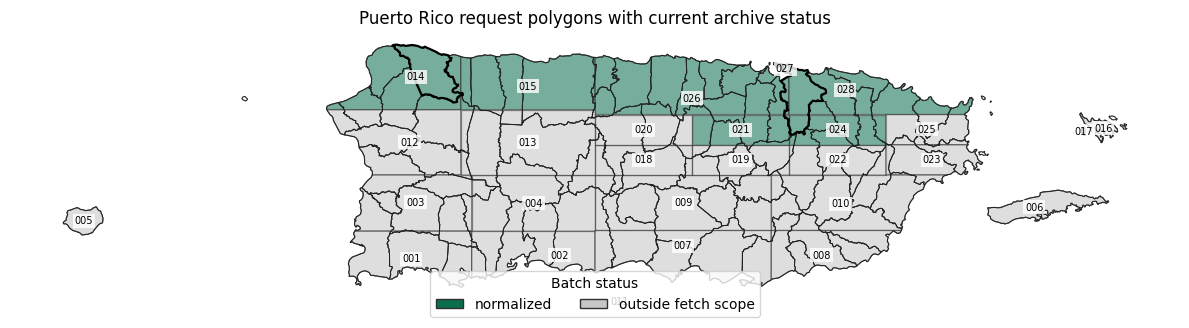

In [8]:
if request_batch_status.empty:
    print("No request-batch status table is available.")
else:
    batch_status_summary = workflow.build_batch_status_summary(request_batch_status)
    if not batch_status_summary.empty:
        print(batch_status_summary.to_string(index=False))
    ledger_activity_summary = workflow.build_ledger_activity_summary()
    if not ledger_activity_summary.empty:
        print(ledger_activity_summary.to_string(index=False))
        csv_dry_runs = int(
            ledger_activity_summary.loc[
                (ledger_activity_summary["request_format"] == "csv")
                & (ledger_activity_summary["status"] == "dry_run"),
                "request_count",
            ].sum()
        )
        if csv_dry_runs:
            print(f"CSV dry-run note: {csv_dry_runs:,} rows represent older point-year fallback planning only.")
    workflow.preview_table(
        "request batch status",
        request_batch_status[
            [
                "batch_id",
                "display_status",
                "site_count",
                "covered_municipalities",
                "fetch_scope_municipalities",
                "normalized_file_count",
                "status_detail",
            ]
        ],
        rows=min(20, len(request_batch_status)),
    )
    workflow.plot_request_status_map(
        all_municipalities,
        request_batch_status,
        fetch_municipalities=fetch_municipalities if workflow.FETCH_SCOPE_MUNICIPALITIES is not None else None,
    )

## Direct CSV Fallback Site Discovery and Request Plan

The direct `.csv` endpoint remains as a fallback when archive generation is
blocked or incomplete. It is restricted to a single point and a single year
per request, so it should be used only after the archive path has been tested.

In [9]:
if workflow.CSV_FALLBACK_MODE == "disabled":
    print("direct CSV fallback skipped because NSRDB_CSV_FALLBACK_MODE=disabled.")
elif fetch_area_geometry is None:
    print("direct CSV fallback skipped because the current fetch scope does not define a geometry.")
elif not workflow.NSRDB_EMAIL:
    print("NSRDB_EMAIL (or EMAIL) is not configured; direct CSV discovery requires an email parameter.")
elif not workflow.REBUILD_SITE_DISCOVERY and workflow.DISCOVERED_SITES_PATH.exists():
    discovered_sites = gpd.read_parquet(workflow.DISCOVERED_SITES_PATH)
    site_discovery_log = pd.read_parquet(workflow.SITE_DISCOVERY_LOG_PATH) if workflow.SITE_DISCOVERY_LOG_PATH.exists() else pd.DataFrame()
    print(f"reused {len(discovered_sites):,} discovered NSRDB sites from {workflow.DISCOVERED_SITES_PATH}")
else:
    discovery_points = workflow.build_candidate_discovery_points(fetch_area_geometry)
    print(f"candidate discovery points: {len(discovery_points):,} across {workflow.DISCOVERY_MAX_PASSES} pass(es)")
    if workflow.MAX_SITE_PROBES_THIS_RUN is not None:
        print(f"site probes limited this run: {workflow.MAX_SITE_PROBES_THIS_RUN:,}")

    discovered_sites, site_discovery_log = workflow.discover_sites_from_points(
        discovery_points,
        target_geometry=fetch_area_geometry,
        api_key=workflow.NSRDB_API_KEY,
        email=workflow.NSRDB_EMAIL,
        year=workflow.DISCOVERY_YEAR,
        attributes=workflow.DISCOVERY_ATTRIBUTES,
        interval_minutes=workflow.DISCOVERY_INTERVAL_MINUTES,
        expected_site_count=fetch_area_site_count,
        max_requests=workflow.MAX_SITE_PROBES_THIS_RUN,
    )
    workflow.DISCOVERED_SITES_PATH.parent.mkdir(parents=True, exist_ok=True)
    discovered_sites.to_parquet(workflow.DISCOVERED_SITES_PATH, index=False)
    if not site_discovery_log.empty:
        site_discovery_log.to_parquet(workflow.SITE_DISCOVERY_LOG_PATH, index=False)

if not discovered_sites.empty:
    site_coverage_pct = (len(discovered_sites) / fetch_area_site_count) * 100.0 if fetch_area_site_count else 0.0
    print(f"discovered unique sites: {len(discovered_sites):,} / {fetch_area_site_count:,} ({site_coverage_pct:.1f}%)")
    if not site_discovery_log.empty:
        print(site_discovery_log.groupby("status").size().to_string())

    csv_request_plan = workflow.build_csv_request_plan(discovered_sites, years=workflow.YEARS)
    workflow.CSV_REQUEST_PLAN_PATH.parent.mkdir(parents=True, exist_ok=True)
    csv_request_plan.to_parquet(workflow.CSV_REQUEST_PLAN_PATH, index=False)
    print(f"csv request plan rows: {len(csv_request_plan):,}")
    print(f"csv request plan parquet: {workflow.CSV_REQUEST_PLAN_PATH}")
    estimated_days = int(np.ceil(len(csv_request_plan) / workflow.CSV_DAILY_REQUEST_LIMIT)) if len(csv_request_plan) else 0
    print(f"minimum days at {workflow.CSV_DAILY_REQUEST_LIMIT:,} direct CSV requests/day: {estimated_days}")
    print(csv_request_plan[["site_id", "year", "status", "raw_csv_exists", "normalized_parquet_exists"]].head(10).to_string(index=False))

direct CSV fallback skipped because NSRDB_CSV_FALLBACK_MODE=disabled.


## Optional Direct CSV Downloads

`NSRDB_CSV_FALLBACK_MODE=execute` runs the point-year fallback requests. Any
other mode stops at planning so the ledger is not flooded with dry-run rows.

In [10]:
if csv_request_plan.empty:
    print("No CSV fallback request plan is available.")
elif not workflow.FETCH_CSV_REQUESTS:
    print(f"direct CSV downloads not executed because NSRDB_CSV_FALLBACK_MODE={workflow.CSV_FALLBACK_MODE}.")
    workflow.preview_table(
        "csv request plan",
        csv_request_plan[["site_id", "year", "status", "raw_csv_exists", "normalized_parquet_exists"]],
        rows=min(10, len(csv_request_plan)),
    )
else:
    if not workflow.NSRDB_EMAIL:
        raise RuntimeError("NSRDB_EMAIL (or EMAIL) must be configured before executing direct CSV requests.")

    csv_download_rows = workflow.download_csv_request_plan(
        csv_request_plan,
        api_key=workflow.NSRDB_API_KEY,
        email=workflow.NSRDB_EMAIL,
        ledger_path=workflow.DEFAULT_LEDGER_PATH,
        max_requests=workflow.MAX_CSV_DOWNLOADS_THIS_RUN,
        dry_run=False,
        pause_seconds=workflow.CSV_REQUEST_PAUSE_SECONDS,
        overwrite_existing=workflow.OVERWRITE_EXISTING_CSV,
        utc=workflow.REQUEST_UTC,
        leap_day=workflow.INCLUDE_LEAP_DAY,
    )
    if not csv_download_rows.empty:
        print(csv_download_rows[["batch_id", "status", "http_status", "local_archive_path"]].to_string(index=False))

ledger_activity_summary = workflow.build_ledger_activity_summary()
if not ledger_activity_summary.empty:
    print(ledger_activity_summary.to_string(index=False))

No CSV fallback request plan is available.
request_format     status  request_count
          json downloaded              7
          json  extracted              7
          json  submitted              7


## Draft Monthly and Annual Flux Means

Once normalized NSRDB parquet files are available under
`data/tabular/nsrdb/normalized/`, this cell derives the site-level monthly
means, site-level annual means, and a multi-year mean table that can be
spatially joined downstream to municipalities, tracts, block groups, or
buildings.

monthly flux means written to /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/normalized/san_juan_isabela_nsrdb_monthly_flux_means.parquet
annual flux means written to /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/normalized/san_juan_isabela_nsrdb_annual_flux_means.parquet
multi-year flux means written to /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/nsrdb/normalized/san_juan_isabela_nsrdb_multiyear_flux_means.parquet
monthly flux means: 46,284 rows
 site_id  latitude  longitude  year  month        ghi        dni       dhi  air_temperature  clearsky_ghi  clearsky_dni  clearsky_dhi  surface_albedo
 6354963     18.36     -67.27  2018      1 177.007392 214.107527 56.695565        26.533199    225.648522    333.741935     36.039651        0.056452
 6354963     18.36     -67.27  2018      2 218.838542 266.386161 57.517113        25.748661    261.581101    358.269345     39.058036        0.060357
 6354963     18.36     -67.27  2018   

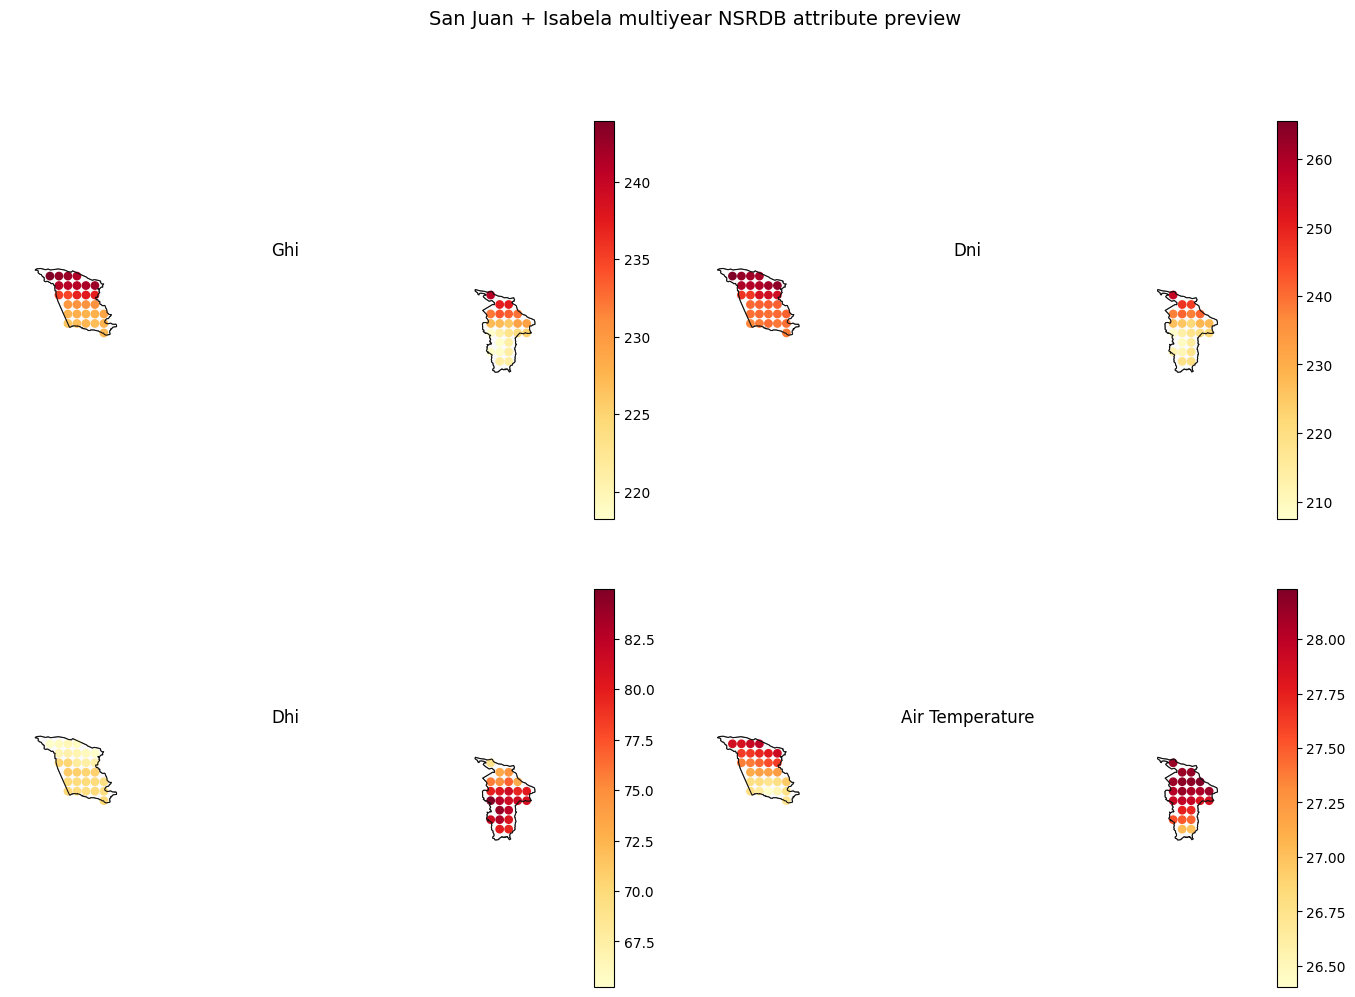

In [11]:
normalized_timeseries = workflow.load_normalized_nsrdb_timeseries()
normalized_timeseries = workflow.filter_timeseries_to_target_municipalities(
    normalized_timeseries,
    workflow.FETCH_SCOPE_MUNICIPALITIES,
)
if normalized_timeseries.empty:
    print(f"flux-mean summaries skipped: no normalized NSRDB parquet files found under {workflow.NORMALIZED_ROOT}")
else:
    monthly_flux_means, annual_flux_means, multiyear_flux_means = workflow.build_flux_mean_tables(normalized_timeseries)
    workflow.write_flux_mean_tables(monthly_flux_means, annual_flux_means, multiyear_flux_means)
    print(f"monthly flux means written to {workflow.MONTHLY_FLUX_MEANS_PATH}")
    print(f"annual flux means written to {workflow.ANNUAL_FLUX_MEANS_PATH}")
    print(f"multi-year flux means written to {workflow.MULTIYEAR_FLUX_MEANS_PATH}")
    workflow.preview_table("monthly flux means", monthly_flux_means)
    workflow.preview_table("annual flux means", annual_flux_means)
    workflow.preview_table("multi-year flux means", multiyear_flux_means)
    flux_preview_municipalities = (
        fetch_municipalities if workflow.FETCH_SCOPE_MUNICIPALITIES is not None and not fetch_municipalities.empty else all_municipalities
    )
    flux_preview_label = workflow.FETCH_SCOPE_LABEL if workflow.FETCH_SCOPE_MUNICIPALITIES is not None else workflow.PLAN_SCOPE_LABEL
    workflow.plot_flux_attribute_preview(flux_preview_municipalities, multiyear_flux_means, focus_label=flux_preview_label)

for path in [
    workflow.REQUEST_PLAN_PATH,
    workflow.ARCHIVE_MANIFEST_PATH,
    workflow.DISCOVERED_SITES_PATH,
    workflow.CSV_REQUEST_PLAN_PATH,
    workflow.MONTHLY_FLUX_MEANS_PATH,
    workflow.ANNUAL_FLUX_MEANS_PATH,
    workflow.MULTIYEAR_FLUX_MEANS_PATH,
]:
    print(f"{path} :: {'present' if Path(path).exists() else 'missing'}")